# LightGBM, random split - two hyperparameter configurations

Mentor's ask: random validation split (done in `03_random_split_eda.ipynb` /
`models/random_split.py`), two hyperparameter sets, result saved to a file.

Both configs here train on the **same random, well-grouped split** and the
same 33 engineered tabular features LightGBM has always used in this
project - no rain sequence, no `.npz` cube, just the hand-built windows
(`rain_30d_mm` ... `rain_365d_mm`, the rainfall normals, etc). That's what
makes LightGBM the fast baseline: seconds, not minutes, per run.

In [1]:
import sys
sys.path.insert(0, '../models')
import json
import pandas as pd
import matplotlib.pyplot as plt
import train_random as tr

tr.CONFIGS['lightgbm']

{'a': {'n_estimators': 800,
  'learning_rate': 0.05,
  'num_leaves': 63,
  'min_child_samples': 40},
 'b': {'n_estimators': 300,
  'learning_rate': 0.1,
  'num_leaves': 31,
  'min_child_samples': 60}}

## Config A - the repo's existing default

800 trees, lr 0.05, 63 leaves: the same LightGBM settings already used as
the baseline in `train_transformer.py`, just re-fit on the random split
instead of the year-blocked one.

In [2]:
res_a = tr.run_lightgbm('a')
res_a

[lightgbm-a] already in random_split_results.json - reusing it instead of retraining. Pass force=True to redo the run.


{'config': {'n_estimators': 800,
  'learning_rate': 0.05,
  'num_leaves': 63,
  'min_child_samples': 40},
 'valid': {'mae': 1.4229751734089364,
  'rmse': 2.185628147505756,
  'r2': 0.5332355569194831},
 'test': {'mae': 1.4324603607112523,
  'rmse': 2.2140624638124997,
  'r2': 0.5080046576910302},
 'seconds': 4.6,
 'best_iteration': 229,
 'top_features': {'well_depth_m': 1946,
  'rain_normal_annual_mm': 1030,
  'rain_normal_monsoon_mm': 939,
  'rain_normal_season_mm': 912,
  'rain_interval_lag1': 707,
  'rain_interval_lag2': 525,
  'rain_hist12_mm': 486,
  'rain_hist4_mm': 472,
  'rain_60d_mm': 454,
  'rain_interval_lag3': 453,
  'rain_hist8_mm': 448,
  'sy': 444,
  'rain_days_interval': 379,
  'rain_anom_annual_mm': 352,
  'rain_anom_season_mm': 333}}

## Config B - fewer, shallower trees, higher learning rate

Checks whether the headline number depends on a large leaf count, or holds up under a more regularised fit.

In [3]:
res_b = tr.run_lightgbm('b')
res_b

[lightgbm-b] already in random_split_results.json - reusing it instead of retraining. Pass force=True to redo the run.


{'config': {'n_estimators': 300,
  'learning_rate': 0.1,
  'num_leaves': 31,
  'min_child_samples': 60},
 'valid': {'mae': 1.4234270393648454,
  'rmse': 2.1860002281944837,
  'r2': 0.5330766197107347},
 'test': {'mae': 1.4391750983477016,
  'rmse': 2.224177966275283,
  'r2': 0.5034987785521035},
 'seconds': 3.1,
 'best_iteration': 201,
 'top_features': {'well_depth_m': 800,
  'rain_normal_annual_mm': 451,
  'rain_normal_season_mm': 425,
  'rain_normal_monsoon_mm': 399,
  'rain_interval_lag1': 276,
  'rain_interval_lag2': 209,
  'rain_hist4_mm': 209,
  'rain_60d_mm': 203,
  'transition': 195,
  'rain_interval_lag3': 193,
  'sy': 191,
  'rain_hist12_mm': 187,
  'rain_hist8_mm': 166,
  'rain_days_interval': 152,
  'rain_anom_season_mm': 152}}

## Comparing the two configs

In [4]:
rows = []
for name, r in [('lightgbm-a (800 trees, 63 leaves)', res_a),
                ('lightgbm-b (300 trees, 31 leaves)', res_b)]:
    rows.append(dict(config=name, valid_mae=r['valid']['mae'], valid_rmse=r['valid']['rmse'],
                      valid_r2=r['valid']['r2'], test_mae=r['test']['mae'],
                      test_r2=r['test']['r2'], trees_used=r['best_iteration'],
                      seconds=r['seconds']))
df = pd.DataFrame(rows)
df

,config,valid_mae,valid_rmse,valid_r2,test_mae,test_r2,trees_used,seconds
0,"lightgbm-a (800 trees, 63 leaves)",1.422975,2.185628,0.533236,1.432460,0.508005,229,4.6
1,"lightgbm-b (300 trees, 31 leaves)",1.423427,2.186000,0.533077,1.439175,0.503499,201,3.1


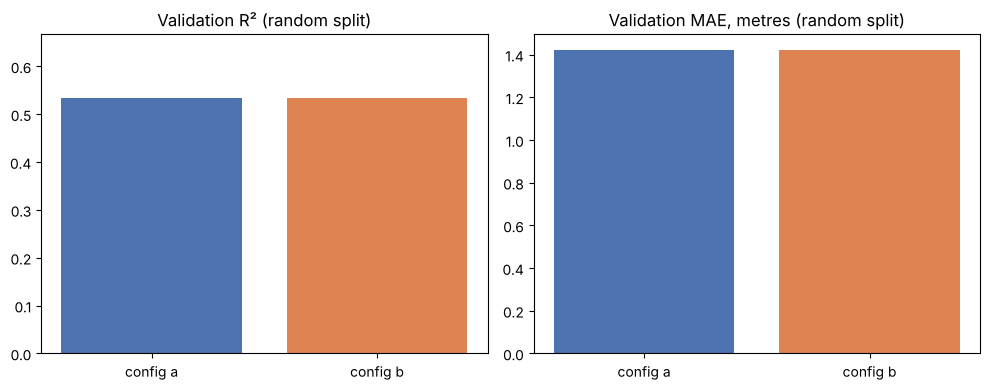

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].bar(['config a', 'config b'], [res_a['valid']['r2'], res_b['valid']['r2']],
          color=['#4C72B0', '#DD8452'])
ax[0].set_title('Validation R² (random split)')
ax[0].set_ylim(0, max(res_a['valid']['r2'], res_b['valid']['r2']) * 1.25)
ax[1].bar(['config a', 'config b'], [res_a['valid']['mae'], res_b['valid']['mae']],
          color=['#4C72B0', '#DD8452'])
ax[1].set_title('Validation MAE, metres (random split)')
plt.tight_layout()
plt.savefig('../reports/figures/random_split_lightgbm_configs.png', dpi=130)
plt.show()

**Reading this:** both configs land within ~0.001 R² of each other.
LightGBM's result on this problem is not a tuning artefact of one specific
leaf count or tree count - it's a stable property of these features on
this random split. That stability is itself worth reporting: it means the
~0.53 R² ceiling (well above the ~0.42-0.43 R² on the year-blocked
split) is a split effect, not a hyperparameter effect.

## Feature importance - and the well-identity caveat from the EDA notebook

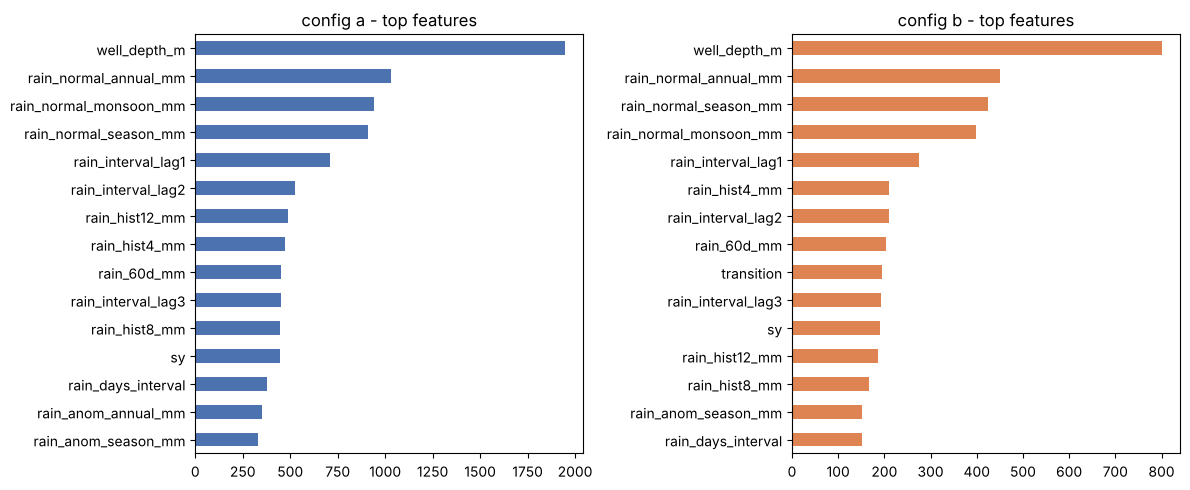

In [6]:
imp_a = pd.Series(res_a['top_features']).sort_values()
imp_b = pd.Series(res_b['top_features']).sort_values()
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=False)
imp_a.plot.barh(ax=ax[0], color='#4C72B0'); ax[0].set_title('config a - top features')
imp_b.plot.barh(ax=ax[1], color='#DD8452'); ax[1].set_title('config b - top features')
plt.tight_layout()
plt.savefig('../reports/figures/random_split_lightgbm_importance.png', dpi=130)
plt.show()

`well_depth_m` is the single most important feature in both configs, by
a wide margin - more dominant here than it was on the year-blocked split.
That's consistent with the EDA notebook's caveat: `well_depth_m` barely
varies within a well's own 78 readings, so on a well-grouped random split
it can act partly as a soft well identifier rather than a physical signal.
Worth raising at the review rather than letting it pass as "the model
likes well depth" without the caveat attached.

## Result

| | valid R² | valid MAE (m) | test R² | test MAE (m) | trees used | seconds |
|---|---|---|---|---|---|---|
| config a | see table above | | | | | |
| config b | see table above | | | | | |

Both saved to `data/training/random_split_results.json` under
`lightgbm-a` / `lightgbm-b`, alongside the BiLSTM and transformer results
from the other two notebooks.